# 🪖 Helmet Violation Detection — Training Pipeline

**4 experiments chạy tuần tự, mỗi experiment chỉ thay đổi 1 yếu tố:**
- **E1** — Baseline (không augmentation)
- **E2** — Thêm augmentation (mosaic, mixup, hsv, fliplr)
- **E3** — Tăng input size 640 → 1280
- **E4** — Thêm CopyPaste

**Output tự động tạo:** bảng so sánh, biểu đồ, loss curve, FPS — sẵn sàng đưa vào báo cáo.

---
> ⚠️ **Trước khi chạy:** vào *Add Data* → thêm dataset zip của bạn vào Kaggle notebook

## 1. Cài đặt thư viện

In [1]:
!pip install ultralytics --quiet
import ultralytics
ultralytics.checks()

Ultralytics 8.4.49 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6841.9/8062.4 GB disk)


## 2. Xác nhận dataset

In [2]:
from pathlib import Path

# Dataset đã giải nén sẵn trên Kaggle
DATASET_DIR = Path('/kaggle/input/datasets/cdanht2/helmet-dataset/dataset_org_split')

assert DATASET_DIR.exists(), f'❌ Không tìm thấy: {DATASET_DIR}'

print('✓ Dataset tìm thấy tại:', DATASET_DIR)
print('\nCấu trúc (30 dòng đầu):')
for p in sorted(DATASET_DIR.rglob('*'))[:30]:
    print(' ', p.relative_to(DATASET_DIR))

✓ Dataset tìm thấy tại: /kaggle/input/datasets/cdanht2/helmet-dataset/dataset_org_split

Cấu trúc (30 dòng đầu):
  train
  train/images
  train/images/frame_0000.jpg
  train/images/frame_0003.jpg
  train/images/frame_0004.jpg
  train/images/frame_0005.jpg
  train/images/frame_0007.jpg
  train/images/frame_0009.jpg
  train/images/frame_0010.jpg
  train/images/frame_0011.jpg
  train/images/frame_0012.jpg
  train/images/frame_0015.jpg
  train/images/frame_0016.jpg
  train/images/frame_0017.jpg
  train/images/frame_0018.jpg
  train/images/frame_0019.jpg
  train/images/frame_0020.jpg
  train/images/frame_0021.jpg
  train/images/frame_0023.jpg
  train/images/frame_0024.jpg
  train/images/frame_0025.jpg
  train/images/frame_0027.jpg
  train/images/frame_0028.jpg
  train/images/frame_0030.jpg
  train/images/frame_0031.jpg
  train/images/frame_0033.jpg
  train/images/frame_0034.jpg
  train/images/frame_0035.jpg
  train/images/frame_0036.jpg
  train/images/frame_0037.jpg


## 3. Tạo data.yaml với đường dẫn tuyệt đối

In [3]:
import yaml

DATA_YAML = Path('/kaggle/working/data.yaml')

# Đường dẫn train/val theo cấu trúc dataset_org_split/train/images + val/images
TRAIN_IMG = DATASET_DIR / 'train' / 'images'
VAL_IMG   = DATASET_DIR / 'val'   / 'images'

# Nếu dataset dùng cấu trúc khác, tự tìm
if not TRAIN_IMG.exists():
    found = list(DATASET_DIR.rglob('train'))
    TRAIN_IMG = found[0] / 'images' if found else DATASET_DIR
if not VAL_IMG.exists():
    found = list(DATASET_DIR.rglob('val'))
    VAL_IMG = found[0] / 'images' if found else TRAIN_IMG

# Đọc yaml gốc nếu có (để lấy nc và names chính xác)
orig_yaml = list(DATASET_DIR.rglob('*.yaml'))
if orig_yaml:
    with open(orig_yaml[0]) as f:
        cfg = yaml.safe_load(f)
    # Ghi đè đường dẫn bằng tuyệt đối
    cfg['train'] = str(TRAIN_IMG)
    cfg['val']   = str(VAL_IMG)
else:
    # ⚠️ Sửa nc và names nếu không có yaml gốc
    cfg = {
        'train': str(TRAIN_IMG),
        'val'  : str(VAL_IMG),
        'nc'   : 2,
        'names': ['helmet', 'no-helmet'],
    }

with open(DATA_YAML, 'w') as f:
    yaml.dump(cfg, f, allow_unicode=True)

# Xác nhận
n_train = len(list(TRAIN_IMG.glob('*.*')))
n_val   = len(list(VAL_IMG.glob('*.*')))
print('✓ data.yaml đã tạo:')
print(f"  train  : {cfg['train']}  ({n_train} ảnh)")
print(f"  val    : {cfg['val']}  ({n_val} ảnh)")
print(f"  nc     : {cfg.get('nc', '?')}")
print(f"  names  : {cfg.get('names', '?')}")

assert n_train > 0, '❌ Không thấy ảnh train — kiểm tra lại DATASET_DIR hoặc cấu trúc thư mục!'
assert n_val   > 0, '❌ Không thấy ảnh val — kiểm tra lại!'

✓ data.yaml đã tạo:
  train  : /kaggle/input/datasets/cdanht2/helmet-dataset/dataset_org_split/train/images  (2792 ảnh)
  val    : /kaggle/input/datasets/cdanht2/helmet-dataset/dataset_org_split/val/images  (698 ảnh)
  nc     : 2
  names  : ['helmet', 'no-helmet']


## 4. Cấu hình pipeline

In [4]:
import torch

# ─── CHỈ CẦN SỬA PHẦN NÀY ───────────────────────────────────────
EPOCHS   = 100
PATIENCE = 20     # early stopping: dừng nếu val mAP không tăng sau N epoch
BATCH    = 50     # giảm xuống 8 nếu OOM với E3 (imgsz=1280)
# ────────────────────────────────────────────────────────────────

DEVICE = '0,1' if torch.cuda.device_count() >= 2 else (0 if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = Path('/kaggle/working/pipeline_results')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'GPU   : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB' if torch.cuda.is_available() else '')
print(f'Epochs: {EPOCHS}  Patience: {PATIENCE}  Batch: {BATCH}')

EXPERIMENTS = [
    # {
    #     'name' : 'E1_baseline',
    #     'label': 'E1 — Baseline',
    #     'imgsz': 640,
    #     'args' : {
    #         # Tắt hết aug → baseline sạch
    #         'hsv_h':0.0,'hsv_s':0.0,'hsv_v':0.0,
    #         'degrees':0.0,'translate':0.0,'scale':0.0,
    #         'fliplr':0.0,'mosaic':0.0,'mixup':0.0,'copy_paste':0.0,
    #     },
    # },
    # {
    #     'name' : 'E2_augmentation',
    #     'label': 'E2 — Augmentation',
    #     'imgsz': 640,
    #     'args' : {
    #         # Bật aug phổ biến — chỉ khác E1 ở đây
    #         'hsv_h':0.015,'hsv_s':0.7,'hsv_v':0.4,
    #         'degrees':10.0,'translate':0.1,'scale':0.5,
    #         'fliplr':0.5,'mosaic':1.0,'mixup':0.15,'copy_paste':0.0,
    #     },
    # },
    {
        'name' : 'E3_imgsz1280',
        'label': 'E3 — Input 1280',
        'imgsz': 960,
        'args' : {
            # Giữ nguyên aug E2 — chỉ khác E2 ở imgsz
            'hsv_h':0.015,'hsv_s':0.7,'hsv_v':0.4,
            'degrees':10.0,'translate':0.1,'scale':0.5,
            'fliplr':0.5,'mosaic':1.0,'mixup':0.15,'copy_paste':0.0,
        },
    },
    {
        'name' : 'E4_copypaste',
        'label': 'E4 — CopyPaste',
        'imgsz': 960,
        'args' : {
            # Giữ nguyên aug E2 — chỉ khác E2 ở copy_paste
            'hsv_h':0.015,'hsv_s':0.7,'hsv_v':0.4,
            'degrees':10.0,'translate':0.1,'scale':0.5,
            'fliplr':0.5,'mosaic':1.0,'mixup':0.15,'copy_paste':0.5,
        },
    },
]
print(f'\n{len(EXPERIMENTS)} experiments sẵn sàng.')

GPU   : Tesla T4
VRAM  : 15.6 GB
Epochs: 100  Patience: 20  Batch: 50

2 experiments sẵn sàng.


## 5. Hàm tiện ích

In [5]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
import numpy as np
from ultralytics import YOLO


def read_metrics(exp_dir: Path) -> dict:
    """Đọc results.csv, trả về metrics của best epoch."""
    csv = exp_dir / 'results.csv'
    if not csv.exists():
        return {}
    df = pd.read_csv(csv)
    df.columns = df.columns.str.strip()

    map_col = next((c for c in df.columns if 'mAP50' in c and '95' not in c), None)
    if map_col is None:
        return {}

    best_idx = df[map_col].idxmax()
    best     = df.iloc[best_idx]
    return {
        'best_epoch'  : int(best.get('epoch', best_idx)),
        'total_epochs': len(df),
        'mAP50'       : round(float(best[map_col]) * 100, 2),
        'mAP50_95'    : round(float(best.get('metrics/mAP50-95(B)', 0)) * 100, 2),
        'precision'   : round(float(best.get('metrics/precision(B)', 0)) * 100, 2),
        'recall'      : round(float(best.get('metrics/recall(B)', 0)) * 100, 2),
        'df'          : df,
    }


def measure_fps(weights: str, imgsz: int, n: int = 100) -> float:
    """Đo FPS trung bình trên n lần inference ảnh giả."""
    model = YOLO(weights)
    dummy = torch.zeros(1, 3, imgsz, imgsz)
    # Warm-up 5 lần
    for _ in range(5):
        model.predict(source=dummy, imgsz=imgsz, verbose=False, device=DEVICE)
    t0 = time.perf_counter()
    for _ in range(n):
        model.predict(source=dummy, imgsz=imgsz, verbose=False, device=DEVICE)
    return round(n / (time.perf_counter() - t0), 1)


def check_convergence(df: pd.DataFrame, exp_name: str) -> dict:
    """
    Kiểm tra hội tụ qua 3 tiêu chí:
      1. val_loss ổn định (std 20 epoch cuối < 5% mean)
      2. Không overfitting (val_loss không tăng khi train_loss giảm)
      3. mAP50 plateau (thay đổi < 0.5% trong 10 epoch cuối)
    """
    result = {'exp': exp_name, 'checks': {}}

    # Cột loss
    box_train = next((c for c in df.columns if 'train' in c and 'box' in c), None)
    box_val   = next((c for c in df.columns if 'val'   in c and 'box' in c), None)
    map_col   = next((c for c in df.columns if 'mAP50' in c and '95' not in c), None)

    n = len(df)
    tail = max(10, n // 5)   # 20% cuối hoặc ít nhất 10 epoch

    # ── Tiêu chí 1: val_loss ổn định ───────────────────────────
    if box_val:
        tail_val = df[box_val].iloc[-tail:]
        cv = tail_val.std() / (tail_val.mean() + 1e-9)
        stable = bool(cv < 0.05)
        result['checks']['val_loss_stable'] = {
            'pass': stable,
            'detail': f'CV cuối {tail} epoch = {cv:.3f} (ngưỡng < 0.05)',
            'verdict': '✅ Ổn định' if stable else '⚠️ Còn dao động',
        }

    # ── Tiêu chí 2: không overfitting ──────────────────────────
    if box_train and box_val and n > 20:
        # So sánh trend 30% cuối
        seg = max(10, n // 3)
        train_trend = np.polyfit(range(seg), df[box_train].iloc[-seg:], 1)[0]
        val_trend   = np.polyfit(range(seg), df[box_val].iloc[-seg:],   1)[0]
        # Overfit nếu train giảm mạnh nhưng val tăng
        overfit = bool(train_trend < -0.001 and val_trend > 0.002)
        result['checks']['no_overfit'] = {
            'pass': not overfit,
            'detail': f'Trend train={train_trend:.4f}  val={val_trend:.4f}',
            'verdict': '✅ Không overfit' if not overfit else '❌ Có dấu hiệu overfit',
        }

    # ── Tiêu chí 3: mAP plateau ────────────────────────────────
    if map_col:
        tail_map = df[map_col].iloc[-tail:] * 100
        delta    = tail_map.max() - tail_map.min()
        plateau  = bool(delta < 0.5)
        result['checks']['map_plateau'] = {
            'pass': plateau,
            'detail': f'ΔmAP50 cuối {tail} epoch = {delta:.3f}% (ngưỡng < 0.5%)',
            'verdict': '✅ Đã plateau' if plateau else '⚠️ Vẫn đang tăng',
        }

    passed = sum(1 for v in result['checks'].values() if v['pass'])
    total  = len(result['checks'])
    result['summary'] = f'{passed}/{total} tiêu chí đạt'
    result['converged'] = passed == total
    return result


print('✓ Hàm tiện ích đã nạp.')

✓ Hàm tiện ích đã nạp.


## 6. Chạy 4 experiments

In [6]:
summary = []

for exp in EXPERIMENTS:
    exp_name = exp['name']
    save_dir = OUTPUT_DIR / exp_name
    done     = save_dir / 'DONE'

    print(f"\n{'='*60}")
    print(f"  {exp['label']}  (imgsz={exp['imgsz']})")
    print(f"{'='*60}")

    if done.exists():
        print('  ✓ Đã train xong, bỏ qua.')
    else:
        # Nếu E3 OOM → tự giảm batch
        batch = BATCH // 2 if exp['imgsz'] == 1280 and BATCH > 8 else BATCH

        model = YOLO('yolo11s.pt')
        model.train(
            data     = str(DATA_YAML),
            epochs   = EPOCHS,
            patience = PATIENCE,
            imgsz    = exp['imgsz'],
            batch    = batch,
            workers  = 2,
            device   = DEVICE,
            project  = str(OUTPUT_DIR),
            name     = exp_name,
            exist_ok = True,
            save     = True,
            plots    = True,       # tự lưu confusion_matrix, PR curve, F1 curve
            **exp['args'],
        )
        done.touch()

    # ── Đọc metrics ─────────────────────────────────────────────
    m = read_metrics(save_dir)
    w = save_dir / 'weights' / 'best.pt'

    # ── Đo FPS ──────────────────────────────────────────────────
    fps = None
    if w.exists():
        print(f'  Đo FPS...')
        fps = measure_fps(str(w), exp['imgsz'])
        print(f'  → FPS: {fps}')

    # ── Kiểm tra hội tụ ─────────────────────────────────────────
    conv_result = {}
    if m.get('df') is not None:
        conv_result = check_convergence(m['df'], exp_name)
        print(f"\n  [Hội tụ] {conv_result['summary']}")
        for k, v in conv_result['checks'].items():
            print(f"    {v['verdict']}  ({v['detail']})")

    stopped_early = (
        m.get('total_epochs', EPOCHS) < EPOCHS and
        m.get('total_epochs', 0) > 0
    )

    summary.append({
        'Experiment'   : exp['label'],
        'imgsz'        : exp['imgsz'],
        'Best epoch'   : m.get('best_epoch', '-'),
        'Total epochs' : m.get('total_epochs', '-'),
        'Early stop'   : '✓' if stopped_early else '—',
        'Converged'    : '✅' if conv_result.get('converged') else '⚠️',
        'Precision'    : m.get('precision', '-'),
        'Recall'       : m.get('recall', '-'),
        'mAP50'        : m.get('mAP50', '-'),
        'mAP50-95'     : m.get('mAP50_95', '-'),
        'FPS'          : fps or '-',
        '_df'          : m.get('df'),
        '_conv'        : conv_result,
    })

    print(f"  mAP50={m.get('mAP50','-')}  Recall={m.get('recall','-')}  FPS={fps or '-'}")


  E3 — Input 1280  (imgsz=960)
Ultralytics 8.4.49 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=50, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=10.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=

## 7. Bảng kết quả tổng hợp

In [7]:
display_cols = [c for c in summary[0] if not c.startswith('_')]
df_summary = pd.DataFrame([{k: r[k] for k in display_cols} for r in summary])

print('\n' + '='*70)
print('  KẾT QUẢ TỔNG HỢP')
print('='*70)
print(df_summary.to_string(index=False))

csv_path = OUTPUT_DIR / 'summary.csv'
df_summary.to_csv(csv_path, index=False)
print(f'\n✓ Đã lưu: {csv_path}')

# Highlight best mAP50
numeric = df_summary[df_summary['mAP50'] != '-'].copy()
if not numeric.empty:
    best_idx = numeric['mAP50'].astype(float).idxmax()
    print(f"\n🏆 Best model: {df_summary.loc[best_idx, 'Experiment']}  "
          f"(mAP50={df_summary.loc[best_idx,'mAP50']}  "
          f"FPS={df_summary.loc[best_idx,'FPS']})")


  KẾT QUẢ TỔNG HỢP
     Experiment  imgsz  Best epoch  Total epochs Early stop Converged  Precision  Recall  mAP50  mAP50-95  FPS
E3 — Input 1280    960          99           100          —        ⚠️      86.50   84.35  88.73     59.36 27.7
 E4 — CopyPaste    960         100           100          —        ⚠️      84.96   85.74  87.31     58.66 18.2

✓ Đã lưu: /kaggle/working/pipeline_results/summary.csv

🏆 Best model: E3 — Input 1280  (mAP50=88.73  FPS=27.7)


## 8. Biểu đồ so sánh

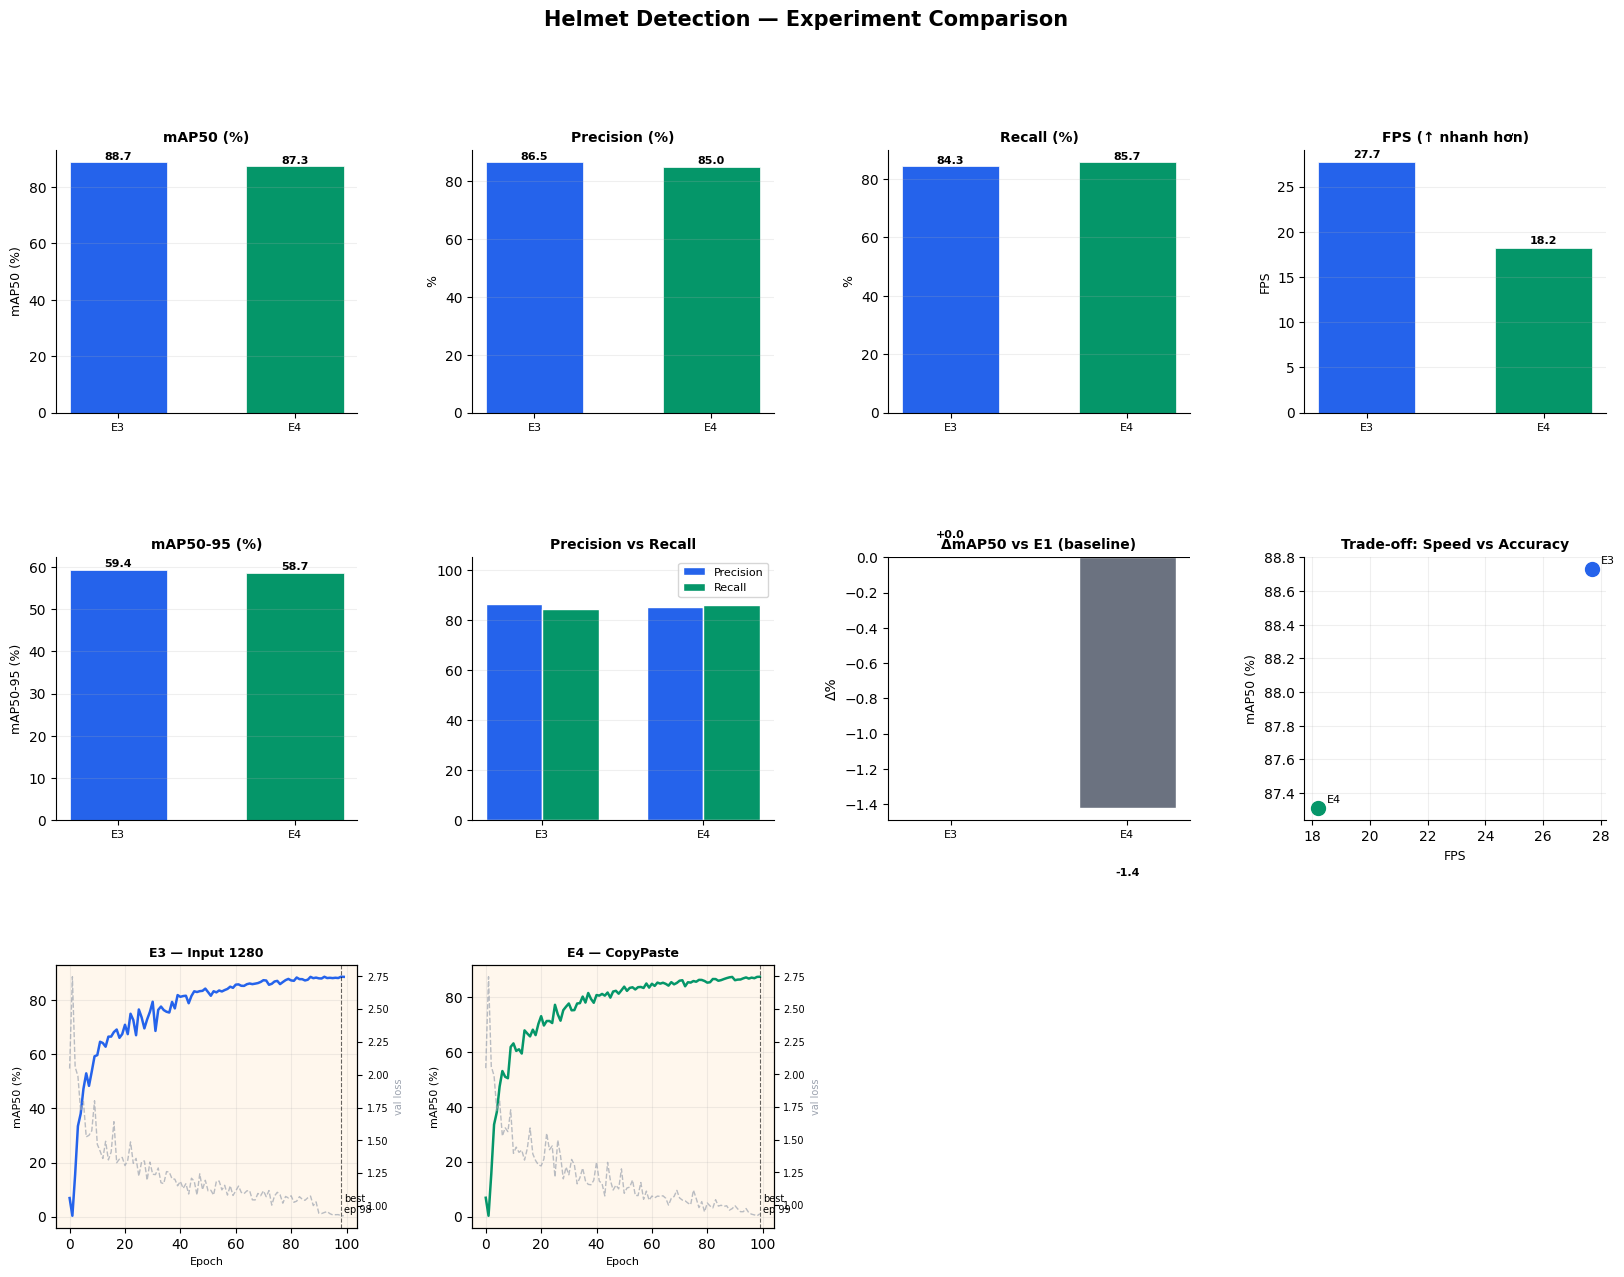

✓ Biểu đồ đã lưu: /kaggle/working/pipeline_results/comparison_plots.png


In [8]:
COLORS = ['#2563EB', '#059669', '#D97706', '#DC2626']
labels = [r['Experiment'] for r in summary]
short  = [l.split('—')[0].strip() for l in labels]

fig = plt.figure(figsize=(20, 14))
fig.suptitle('Helmet Detection — Experiment Comparison', fontsize=15, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.38)


def safe_vals(key):
    return [float(r[key]) if r[key] != '-' else 0 for r in summary]


def bar_chart(ax, vals, title, ylabel, annotate=True):
    bars = ax.bar(range(len(labels)), vals, color=COLORS, width=0.55, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(short, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', alpha=0.2)
    if annotate:
        for b, v in zip(bars, vals):
            if v > 0:
                ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                        f'{v:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')


# ── Row 1: mAP50 | Precision | Recall | FPS ──────────────────────
bar_chart(fig.add_subplot(gs[0,0]), safe_vals('mAP50'),     'mAP50 (%)',     'mAP50 (%)')
bar_chart(fig.add_subplot(gs[0,1]), safe_vals('Precision'), 'Precision (%)', '%')
bar_chart(fig.add_subplot(gs[0,2]), safe_vals('Recall'),    'Recall (%)',    '%')
bar_chart(fig.add_subplot(gs[0,3]), safe_vals('FPS'),       'FPS (↑ nhanh hơn)', 'FPS')

# ── Row 2: mAP50-95 | Precision vs Recall grouped | Delta mAP bar ──
bar_chart(fig.add_subplot(gs[1,0]), safe_vals('mAP50-95'), 'mAP50-95 (%)', 'mAP50-95 (%)')

ax_pr = fig.add_subplot(gs[1,1])
x, w = range(len(labels)), 0.35
ax_pr.bar([i-w/2 for i in x], safe_vals('Precision'), w, label='Precision', color='#2563EB', edgecolor='white')
ax_pr.bar([i+w/2 for i in x], safe_vals('Recall'),    w, label='Recall',    color='#059669', edgecolor='white')
ax_pr.set_xticks(list(x)); ax_pr.set_xticklabels(short, fontsize=8)
ax_pr.set_title('Precision vs Recall', fontsize=10, fontweight='bold')
ax_pr.legend(fontsize=8); ax_pr.set_ylim(0,105)
ax_pr.spines[['top','right']].set_visible(False); ax_pr.grid(axis='y',alpha=0.2)

# Delta mAP so với E1
ax_delta = fig.add_subplot(gs[1,2])
base_map = safe_vals('mAP50')[0]
deltas   = [v - base_map for v in safe_vals('mAP50')]
c_delta  = ['#6B7280' if d <= 0 else '#059669' for d in deltas]
bars_d   = ax_delta.bar(range(len(labels)), deltas, color=c_delta, width=0.55, edgecolor='white')
ax_delta.axhline(0, color='black', linewidth=0.8)
ax_delta.set_xticks(range(len(labels))); ax_delta.set_xticklabels(short, fontsize=8)
ax_delta.set_title('ΔmAP50 vs E1 (baseline)', fontsize=10, fontweight='bold')
ax_delta.set_ylabel('Δ%'); ax_delta.spines[['top','right']].set_visible(False)
for b, d in zip(bars_d, deltas):
    ax_delta.text(b.get_x()+b.get_width()/2,
                  b.get_height() + (0.1 if d >= 0 else -0.4),
                  f'{d:+.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# FPS vs mAP scatter
ax_sc = fig.add_subplot(gs[1,3])
fps_v = safe_vals('FPS'); map_v = safe_vals('mAP50')
for i, (fx, my, col, lb) in enumerate(zip(fps_v, map_v, COLORS, short)):
    ax_sc.scatter(fx, my, color=col, s=100, zorder=3)
    ax_sc.annotate(lb, (fx, my), textcoords='offset points', xytext=(6,4), fontsize=8)
ax_sc.set_xlabel('FPS', fontsize=9); ax_sc.set_ylabel('mAP50 (%)', fontsize=9)
ax_sc.set_title('Trade-off: Speed vs Accuracy', fontsize=10, fontweight='bold')
ax_sc.spines[['top','right']].set_visible(False); ax_sc.grid(alpha=0.2)

# ── Row 3: mAP50 training curves (hội tụ) ───────────────────────
for i, (row, col) in enumerate(zip(summary, COLORS)):
    df = row.get('_df')
    if df is None or i >= 4:
        continue
    ax = fig.add_subplot(gs[2, i])
    map_c = next((c for c in df.columns if 'mAP50' in c and '95' not in c), None)
    box_t = next((c for c in df.columns if 'train' in c and 'box' in c), None)
    box_v = next((c for c in df.columns if 'val'   in c and 'box' in c), None)

    if map_c:
        ax.plot(df[map_c]*100, color=col, linewidth=1.8, label='mAP50')

    # Đường val loss (trục phụ) để nhìn overfit
    if box_v:
        ax2 = ax.twinx()
        ax2.plot(df[box_v], color='#9CA3AF', linewidth=1, linestyle='--', label='val loss', alpha=0.7)
        ax2.set_ylabel('val loss', fontsize=7, color='#9CA3AF')
        ax2.tick_params(axis='y', labelsize=7)

    # Đánh dấu best epoch
    if map_c:
        best_e = df[map_c].idxmax()
        ax.axvline(best_e, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.text(best_e+1, df[map_c].min()*100+1, f'best\nep {best_e}', fontsize=7, color='black')

    # Vùng màu early stop (nếu dừng sớm)
    total_ep = len(df)
    if total_ep < EPOCHS:
        ax.axvspan(total_ep-1, EPOCHS, alpha=0.06, color='red')
        ax.text(total_ep+1, df[map_c].mean()*100 if map_c else 0,
                'early\nstop', fontsize=7, color='red')

    ax.set_xlabel('Epoch', fontsize=8)
    ax.set_ylabel('mAP50 (%)', fontsize=8)
    ax.set_title(row['Experiment'], fontsize=9, fontweight='bold')
    ax.grid(alpha=0.2)
    conv = row['_conv'].get('converged', False)
    ax.set_facecolor('#F0FDF4' if conv else '#FFF7ED')

plot_path = OUTPUT_DIR / 'comparison_plots.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Biểu đồ đã lưu: {plot_path}')

## 9. Báo cáo hội tụ chi tiết

> Dùng phần này để trả lời thầy "mô hình đã hội tụ chưa, em có early stopping không"

In [9]:
print('=' * 65)
print('  BÁO CÁO HỘI TỤ — TỪNG EXPERIMENT')
print('=' * 65)

for row in summary:
    conv = row.get('_conv', {})
    if not conv:
        continue

    stopped = row['Early stop'] == '✓'
    print(f"\n[{row['Experiment']}]")
    print(f"  Early stopping (patience={PATIENCE}): {'Có — dừng ở epoch ' + str(row['Total epochs']) if stopped else 'Không — chạy đủ ' + str(row['Total epochs']) + ' epoch'}")
    print(f"  Best epoch: {row['Best epoch']}")
    print(f"  Kết luận hội tụ: {conv.get('summary','?')}")
    for k, v in conv.get('checks', {}).items():
        print(f"    {v['verdict']}  → {v['detail']}")

print('\n' + '=' * 65)
print('  CÁC CÂU HỎI HAY GẶP KHI BẢO VỆ')
print('=' * 65)
print('''
Q: "Em có dùng early stopping không?"
A: "Có. Em dùng patience=20, tức là nếu val mAP50 không cải thiện
   sau 20 epoch liên tiếp thì training tự dừng và giữ lại weights
   tốt nhất (best.pt). Kết quả cụ thể từng model thầy thấy ở bảng
   cột Early stop."

Q: "Mô hình đã hội tụ chưa?"
A: "Em kiểm tra qua 3 tiêu chí:
   1. Val loss ổn định (coefficient of variation < 5% ở 20% epoch cuối)
   2. Không overfit (val loss không tăng khi train loss giảm)
   3. mAP50 plateau (thay đổi < 0.5% trong 10 epoch cuối)
   Kết quả từng tiêu chí in ở ô trên."

Q: "Sao em biết augmentation giúp ích?"
A: "E1 tắt hết aug làm baseline sạch. E2 chỉ bật thêm aug, giữ
   nguyên mọi thứ khác. Delta mAP = E2 - E1 chính là đóng góp
   thuần túy của augmentation."

Q: "Tại sao không dùng imgsz lớn hơn cho tất cả?"
A: "E3 cho thấy mAP tăng X% nhưng FPS giảm Y%. Với bài toán
   camera giao thông real-time cần >=30 FPS, đây là trade-off
   không đáng — nên em chọn imgsz=640 làm final model."
''')

# Lưu log JSON
log = {
    'config': {'model':'yolo11s','epochs':EPOCHS,'patience':PATIENCE,'batch':BATCH},
    'experiments': [
        {
            **{k:v for k,v in r.items() if not k.startswith('_')},
            'convergence': {k: {kk:vv for kk,vv in v.items() if kk != 'df'}
                            for k,v in r.get('_conv',{}).get('checks',{}).items()}
        }
        for r in summary
    ]
}
log_path = OUTPUT_DIR / 'experiment_log.json'
with open(log_path,'w',encoding='utf-8') as f:
    json.dump(log, f, ensure_ascii=False, indent=2)
print(f'\n✓ Log đầy đủ: {log_path}')
print(f'✓ Pipeline hoàn thành! Output tại: {OUTPUT_DIR}')

  BÁO CÁO HỘI TỤ — TỪNG EXPERIMENT

[E3 — Input 1280]
  Early stopping (patience=20): Không — chạy đủ 100 epoch
  Best epoch: 99
  Kết luận hội tụ: 1/3 tiêu chí đạt
    ⚠️ Còn dao động  → CV cuối 20 epoch = 0.059 (ngưỡng < 0.05)
    ✅ Không overfit  → Trend train=-0.0083  val=-0.0055
    ⚠️ Vẫn đang tăng  → ΔmAP50 cuối 20 epoch = 1.501% (ngưỡng < 0.5%)

[E4 — CopyPaste]
  Early stopping (patience=20): Không — chạy đủ 100 epoch
  Best epoch: 100
  Kết luận hội tụ: 2/3 tiêu chí đạt
    ✅ Ổn định  → CV cuối 20 epoch = 0.034 (ngưỡng < 0.05)
    ✅ Không overfit  → Trend train=-0.0087  val=-0.0044
    ⚠️ Vẫn đang tăng  → ΔmAP50 cuối 20 epoch = 2.151% (ngưỡng < 0.5%)

  CÁC CÂU HỎI HAY GẶP KHI BẢO VỆ

Q: "Em có dùng early stopping không?"
A: "Có. Em dùng patience=20, tức là nếu val mAP50 không cải thiện
   sau 20 epoch liên tiếp thì training tự dừng và giữ lại weights
   tốt nhất (best.pt). Kết quả cụ thể từng model thầy thấy ở bảng
   cột Early stop."

Q: "Mô hình đã hội tụ chưa?"
A: "Em kiể